# Persistent-parameter Wasserstein-DRO promotion planning

The previous notebook used a rectangular robust Bellman recursion. That
approximation evaluates the Wasserstein adversary separately inside each
period's continuation problem, even though the behavioral vector

\[
\theta=(\varepsilon,\gamma,\psi,r)
\]

represents persistent consumer behavior.

This notebook replaces that approximation with a whole-horizon
formulation. A behavioral vector is drawn once and remains fixed over the
complete planning horizon. The retailer selects a feasible precommitted
promotion schedule

\[
a=(d_1,\ldots,d_T)\in\mathcal A
\]

and its value under behavioral type \(\theta\) is

\[
V(a;\theta,\alpha)
=
\sum_{t=1}^{T}
\beta^{t-1}
\left[
    p_0(1-d_t)-c+\alpha d_t
\right]
Q_t(a;\theta).
\]

The nominal and distributionally robust schedules solve

\[
a^N(\alpha)
\in
\arg\max_{a\in\mathcal A}
\mathbb E_{\widehat P}
\left[
    V(a;\theta,\alpha)
\right],
\]

and

\[
a^{DRO}(\alpha)
\in
\arg\max_{a\in\mathcal A}
\inf_{Q:\,W_1(Q,\widehat P)\leq\rho}
\mathbb E_Q
\left[
    V(a;\theta,\alpha)
\right].
\]

The adversary therefore distorts the distribution of complete-horizon
behavioral types once, rather than selecting a new adverse type at every
week.

The notebook:

- enumerates every feasible 12-week promotion schedule;
- decomposes every schedule value into an \(\alpha\)-independent component
  and a contract-exposure component;
- solves nominal and persistent-parameter Wasserstein-DRO planning;
- evaluates the selected schedules on the full bootstrap distribution;
- estimates nominal, DRO, myopic, and oracle contract thresholds;
- compares the corrected formulation with the previous rectangular
  feedback approximation when its saved outputs are available.

## 1. Imports and configuration

In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
import json
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.optimize import (
    linear_sum_assignment,
    minimize_scalar,
)
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans

warnings.filterwarnings(
    "ignore",
    category=FutureWarning,
)

CURRENT_DIR = Path.cwd().resolve()
POSSIBLE_ROOTS = [
    CURRENT_DIR,
    CURRENT_DIR.parent,
]

PROJECT_ROOT = next(
    (
        root
        for root in POSSIBLE_ROOTS
        if (
            root
            / "data"
            / "processed"
        ).is_dir()
    ),
    None,
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate project root from {CURRENT_DIR}"
    )

PROCESSED_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
)
TABLE_DIR = (
    PROJECT_ROOT
    / "results"
    / "tables"
)
FIGURE_DIR = (
    PROJECT_ROOT
    / "results"
    / "figures"
)
MODEL_DIR = (
    PROJECT_ROOT
    / "results"
    / "models"
)

for directory in [
    PROCESSED_DIR,
    TABLE_DIR,
    FIGURE_DIR,
    MODEL_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

PARAMETER_PATH = (
    PROCESSED_DIR
    / "stockpiling_behavioral_draws.pkl"
)

RECTANGULAR_THRESHOLD_PATH = (
    TABLE_DIR
    / "contract_thresholds_refined.csv"
)
RECTANGULAR_DIVERGENCE_PATH = (
    TABLE_DIR
    / "contract_policy_divergence_refined.csv"
)

RANDOM_SEED = 42

HORIZON = 12
DISCOUNT_FACTOR = 0.995

DISCOUNT_ACTIONS = np.array(
    [0.00, 0.10, 0.20, 0.30],
    dtype=float,
)

MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION = 2
MAX_PROMOTIONS = 4

MAX_DRO_SCENARIOS = 40

RADIUS_RESAMPLE_REPLICATIONS = 100
RADIUS_RESAMPLE_SIZE = 100
RADIUS_QUANTILE = 0.90

ALPHA_MIN = 2.10
ALPHA_MAX = 2.50
ALPHA_STEP = 0.005

ALPHA_GRID = np.round(
    np.arange(
        ALPHA_MIN,
        ALPHA_MAX
        + 0.5 * ALPHA_STEP,
        ALPHA_STEP,
    ),
    10,
)

PARAMETER_COLUMNS = [
    "price_elasticity",
    "promotion_lift_log",
    "displacement_strength",
    "inventory_persistence",
]

SCHEDULE_TABLE_PATH = (
    TABLE_DIR
    / "persistent_dro_feasible_schedules.csv"
)
THRESHOLD_TABLE_PATH = (
    TABLE_DIR
    / "persistent_dro_contract_thresholds.csv"
)
PERFORMANCE_TABLE_PATH = (
    TABLE_DIR
    / "persistent_dro_contract_performance.csv"
)
PATH_TABLE_PATH = (
    TABLE_DIR
    / "persistent_dro_selected_paths.csv"
)
DIVERGENCE_TABLE_PATH = (
    TABLE_DIR
    / "persistent_dro_divergence_regions.csv"
)
ORACLE_THRESHOLD_PATH = (
    TABLE_DIR
    / "persistent_dro_oracle_thresholds.csv"
)
RECTANGULAR_COMPARISON_PATH = (
    TABLE_DIR
    / "persistent_vs_rectangular_comparison.csv"
)
SEARCH_DIAGNOSTIC_PATH = (
    TABLE_DIR
    / "persistent_dro_search_diagnostics.csv"
)

PROMOTION_FIGURE_PATH = (
    FIGURE_DIR
    / "persistent_dro_promotion_count.png"
)
PATH_FIGURE_PATH = (
    FIGURE_DIR
    / "persistent_dro_selected_schedule.png"
)
REGRET_FIGURE_PATH = (
    FIGURE_DIR
    / "persistent_dro_regret.png"
)
THRESHOLD_FIGURE_PATH = (
    FIGURE_DIR
    / "persistent_vs_rectangular_thresholds.png"
)

ARTIFACT_PATH = (
    PROCESSED_DIR
    / "persistent_parameter_dro_artifact.pkl"
)
CONFIGURATION_PATH = (
    MODEL_DIR
    / "persistent_parameter_dro_configuration.json"
)

VALUE_TOLERANCE = 1e-9

print("Project root:", PROJECT_ROOT)
print("Python:", sys.version.split()[0])
print(
    "Alpha grid:",
    f"{ALPHA_GRID[0]:.3f}",
    "to",
    f"{ALPHA_GRID[-1]:.3f}",
    "with",
    len(ALPHA_GRID),
    "points.",
)

Project root: C:\Users\janza\price-of-extrapolation
Python: 3.13.3
Alpha grid: 2.100 to 2.500 with 81 points.


## 2. Load behavioral draws

In [2]:
if not PARAMETER_PATH.is_file():
    raise FileNotFoundError(
        "Run 04_stockpiling_calibration_revised_v2.ipynb first."
    )

parameter_draws = pd.read_pickle(
    PARAMETER_PATH
).copy()

required_columns = set(
    PARAMETER_COLUMNS
).union(
    {
        "base_demand",
        "regular_price",
        "unit_cost",
        "draw_weight",
    }
)

missing = required_columns.difference(
    parameter_draws.columns
)

if missing:
    raise ValueError(
        "Behavioral-draw artifact is missing columns: "
        f"{sorted(missing)}"
    )

for column in required_columns:
    parameter_draws[column] = pd.to_numeric(
        parameter_draws[column],
        errors="coerce",
    )

valid = np.ones(
    len(parameter_draws),
    dtype=bool,
)

for column in required_columns:
    valid &= (
        parameter_draws[column].notna()
        & np.isfinite(
            parameter_draws[column]
        )
    )

valid &= parameter_draws[
    "draw_weight"
].gt(0)

parameter_draws = (
    parameter_draws.loc[valid]
    .reset_index(drop=True)
)

if len(parameter_draws) < 20:
    raise RuntimeError(
        "At least 20 valid behavioral draws are required."
    )

parameter_draws["draw_weight"] = (
    parameter_draws["draw_weight"]
    / parameter_draws["draw_weight"].sum()
)

DRAW_WEIGHTS = parameter_draws[
    "draw_weight"
].to_numpy(dtype=float)

BASE_DEMAND = float(
    np.average(
        parameter_draws["base_demand"],
        weights=DRAW_WEIGHTS,
    )
)
REGULAR_PRICE = float(
    np.average(
        parameter_draws["regular_price"],
        weights=DRAW_WEIGHTS,
    )
)
UNIT_COST = float(
    np.average(
        parameter_draws["unit_cost"],
        weights=DRAW_WEIGHTS,
    )
)

print("Behavioral draws:", len(parameter_draws))
print("Base demand:", BASE_DEMAND)
print("Regular price:", REGULAR_PRICE)
print("Unit cost:", UNIT_COST)

display(
    parameter_draws[
        PARAMETER_COLUMNS
    ].describe(
        percentiles=[0.05, 0.50, 0.95]
    ).T
)

Behavioral draws: 564
Base demand: 45.99999999999999
Regular price: 2.7299999999999995
Unit cost: 2.341075


,count,mean,std,min,5%,50%,95%,max
price_elasticity,564.0,1.598468,0.171309,0.982965,1.300228,1.590725,1.883569,2.039200
promotion_lift_log,564.0,-0.026968,0.025435,-0.103416,-0.072201,-0.026858,0.011903,0.043898
displacement_strength,564.0,0.143359,0.112766,0.000000,0.000000,0.141243,0.337756,0.468801
inventory_persistence,564.0,0.363067,0.186043,0.050000,0.150000,0.350000,0.600000,0.950000


## 3. Enumerate all feasible precommitted schedules

In [3]:
def enumerate_feasible_schedules(
    horizon: int,
    actions: np.ndarray,
    cooldown_length: int,
    maximum_promotions: int,
) -> np.ndarray:
    schedules: list[
        tuple[float, ...]
    ] = []

    def recurse(
        time_index: int,
        cooldown: int,
        promotion_count: int,
        path: list[float],
    ) -> None:
        if time_index == horizon:
            schedules.append(
                tuple(path)
            )
            return

        if cooldown > 0:
            feasible = [
                0.0
            ]
        else:
            feasible = [
                float(action)
                for action in actions
                if (
                    action <= 1e-12
                    or promotion_count
                    < maximum_promotions
                )
            ]

        for discount_depth in feasible:
            if discount_depth > 1e-12:
                next_cooldown = (
                    cooldown_length
                )
                next_promotion_count = (
                    promotion_count + 1
                )
            else:
                next_cooldown = max(
                    cooldown - 1,
                    0,
                )
                next_promotion_count = (
                    promotion_count
                )

            path.append(
                discount_depth
            )

            recurse(
                time_index + 1,
                next_cooldown,
                next_promotion_count,
                path,
            )

            path.pop()

    recurse(
        time_index=0,
        cooldown=0,
        promotion_count=0,
        path=[],
    )

    return np.asarray(
        schedules,
        dtype=float,
    )


SCHEDULES = (
    enumerate_feasible_schedules(
        horizon=HORIZON,
        actions=DISCOUNT_ACTIONS,
        cooldown_length=(
            MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
        ),
        maximum_promotions=MAX_PROMOTIONS,
    )
)

N_SCHEDULES = len(
    SCHEDULES
)

SCHEDULE_PROMOTION_COUNT = (
    (
        SCHEDULES > 1e-12
    ).sum(axis=1)
)

SCHEDULE_TOTAL_DEPTH = (
    SCHEDULES.sum(axis=1)
)

SCHEDULE_FIRST_PROMOTION_WEEK = np.full(
    N_SCHEDULES,
    np.nan,
    dtype=float,
)

for schedule_index, schedule in enumerate(
    SCHEDULES
):
    promoted = np.flatnonzero(
        schedule > 1e-12
    )

    if len(promoted) > 0:
        SCHEDULE_FIRST_PROMOTION_WEEK[
            schedule_index
        ] = float(
            promoted[0] + 1
        )

NO_PROMOTION_INDEX = int(
    np.flatnonzero(
        SCHEDULE_PROMOTION_COUNT == 0
    )[0]
)

SCHEDULE_LOOKUP = {
    tuple(schedule.tolist()): int(
        schedule_index
    )
    for schedule_index, schedule in enumerate(
        SCHEDULES
    )
}

schedule_table = pd.DataFrame(
    SCHEDULES,
    columns=[
        f"week_{week}"
        for week in range(
            1,
            HORIZON + 1,
        )
    ],
)

schedule_table.insert(
    0,
    "schedule_id",
    np.arange(
        N_SCHEDULES,
        dtype=int,
    ),
)

schedule_table[
    "promotion_count"
] = SCHEDULE_PROMOTION_COUNT

schedule_table[
    "total_discount_depth"
] = SCHEDULE_TOTAL_DEPTH

schedule_table[
    "first_promotion_week"
] = SCHEDULE_FIRST_PROMOTION_WEEK

print(
    "Feasible schedules:",
    f"{N_SCHEDULES:,}",
)
print(
    "No-promotion schedule ID:",
    NO_PROMOTION_INDEX,
)

display(
    schedule_table.groupby(
        "promotion_count",
        observed=True,
    )
    .size()
    .rename(
        "schedule_count"
    )
    .reset_index()
)

Feasible schedules: 3,169
No-promotion schedule ID: 0


,promotion_count,schedule_count
0,0,1
1,1,36
2,2,405
3,3,1512
4,4,1215


## 4. Whole-horizon schedule-value decomposition

Demand does not depend on \(\alpha\). Consequently,

\[
V(a;\theta,\alpha)
=
B(a;\theta)
+
\alpha E(a;\theta),
\]

where

\[
B(a;\theta)
=
\sum_t
\beta^{t-1}
\left[
    p_0(1-d_t)-c
\right]
Q_t,
\]

and

\[
E(a;\theta)
=
\sum_t
\beta^{t-1}d_tQ_t.
\]

This decomposition permits the full contract grid to be evaluated
without resimulating the demand path at every \(\alpha\).

In [4]:
@dataclass(frozen=True)
class BehavioralParameters:
    price_elasticity: float
    promotion_lift_log: float
    displacement_strength: float
    inventory_persistence: float


BEHAVIORAL_DRAWS = [
    BehavioralParameters(
        **{
            column: float(
                row[column]
            )
            for column in PARAMETER_COLUMNS
        }
    )
    for _, row in parameter_draws.iterrows()
]


def schedule_value_components(
    schedule: np.ndarray,
    parameters: BehavioralParameters,
) -> tuple[float, float]:
    inventory = 0.0
    base_value = 0.0
    contract_exposure = 0.0

    for time_index, discount_depth in enumerate(
        schedule
    ):
        discount_depth = float(
            discount_depth
        )

        promotion_active = float(
            discount_depth > 1e-12
        )

        demand = (
            BASE_DEMAND
            * np.power(
                max(
                    1.0
                    - discount_depth,
                    1e-8,
                ),
                -parameters.price_elasticity,
            )
            * np.exp(
                parameters.promotion_lift_log
                * promotion_active
                - parameters.displacement_strength
                * max(
                    inventory,
                    0.0,
                )
            )
        )

        price = (
            REGULAR_PRICE
            * (
                1.0
                - discount_depth
            )
        )

        discount_weight = (
            DISCOUNT_FACTOR
            ** time_index
        )

        base_value += (
            discount_weight
            * (
                price
                - UNIT_COST
            )
            * demand
        )

        contract_exposure += (
            discount_weight
            * discount_depth
            * demand
        )

        inventory = (
            parameters.inventory_persistence
            * max(
                inventory,
                0.0,
            )
            + discount_depth
        )

    return (
        float(base_value),
        float(contract_exposure),
    )


BASE_VALUE_MATRIX = np.empty(
    (
        N_SCHEDULES,
        len(BEHAVIORAL_DRAWS),
    ),
    dtype=np.float32,
)

EXPOSURE_MATRIX = np.empty_like(
    BASE_VALUE_MATRIX
)

for draw_index, parameters in enumerate(
    BEHAVIORAL_DRAWS
):
    for schedule_index, schedule in enumerate(
        SCHEDULES
    ):
        (
            base_value,
            exposure,
        ) = schedule_value_components(
            schedule,
            parameters,
        )

        BASE_VALUE_MATRIX[
            schedule_index,
            draw_index,
        ] = base_value

        EXPOSURE_MATRIX[
            schedule_index,
            draw_index,
        ] = exposure

    if (
        draw_index == 0
        or (
            draw_index + 1
        ) % 50 == 0
        or (
            draw_index + 1
        ) == len(
            BEHAVIORAL_DRAWS
        )
    ):
        print(
            f"Evaluated draw "
            f"{draw_index + 1}/"
            f"{len(BEHAVIORAL_DRAWS)}"
        )

no_promotion_values = (
    BASE_VALUE_MATRIX[
        NO_PROMOTION_INDEX
    ]
)

if not np.allclose(
    EXPOSURE_MATRIX[
        NO_PROMOTION_INDEX
    ],
    0.0,
    atol=1e-10,
):
    raise RuntimeError(
        "The no-promotion schedule has nonzero contract exposure."
    )

print(
    "Value matrices:",
    BASE_VALUE_MATRIX.shape,
)
print(
    "Approximate matrix memory:",
    f"{(
        BASE_VALUE_MATRIX.nbytes
        + EXPOSURE_MATRIX.nbytes
    ) / 1e6:.1f} MB",
)

Evaluated draw 1/564
Evaluated draw 50/564
Evaluated draw 100/564
Evaluated draw 150/564
Evaluated draw 200/564
Evaluated draw 250/564
Evaluated draw 300/564
Evaluated draw 350/564
Evaluated draw 400/564
Evaluated draw 450/564
Evaluated draw 500/564
Evaluated draw 550/564
Evaluated draw 564/564
Value matrices: (3169, 564)
Approximate matrix memory: 14.3 MB


## 5. Reduce the ambiguity distribution and construct transport costs

In [5]:
theta = parameter_draws[
    PARAMETER_COLUMNS
].to_numpy(dtype=float)

theta_mean = np.average(
    theta,
    axis=0,
    weights=DRAW_WEIGHTS,
)

centered = (
    theta
    - theta_mean
)

theta_variance = np.average(
    centered ** 2,
    axis=0,
    weights=DRAW_WEIGHTS,
)

theta_scale = np.sqrt(
    theta_variance
)
theta_scale = np.where(
    theta_scale > 1e-10,
    theta_scale,
    1.0,
)

theta_standardized = (
    theta
    - theta_mean
) / theta_scale

distinct_scenario_count = len(
    np.unique(
        np.round(
            theta_standardized,
            decimals=10,
        ),
        axis=0,
    )
)

scenario_count = min(
    MAX_DRO_SCENARIOS,
    len(parameter_draws),
    distinct_scenario_count,
)

if scenario_count <= 1:
    medoid_indices = np.array(
        [
            int(
                np.argmax(
                    DRAW_WEIGHTS
                )
            )
        ],
        dtype=int,
    )
    scenario_weights = np.array(
        [1.0],
        dtype=float,
    )
elif scenario_count == len(
    parameter_draws
):
    medoid_indices = np.arange(
        len(parameter_draws),
        dtype=int,
    )
    scenario_weights = (
        DRAW_WEIGHTS.copy()
    )
else:
    kmeans = KMeans(
        n_clusters=scenario_count,
        random_state=RANDOM_SEED,
        n_init=20,
    )

    kmeans.fit(
        theta_standardized,
        sample_weight=DRAW_WEIGHTS,
    )

    labels = kmeans.labels_
    medoid_indices_list: list[int] = []
    scenario_weights_list: list[float] = []

    for cluster_id in range(
        scenario_count
    ):
        members = np.flatnonzero(
            labels == cluster_id
        )

        center = (
            kmeans.cluster_centers_[
                cluster_id
            ]
        )

        distances = np.linalg.norm(
            theta_standardized[
                members
            ]
            - center,
            axis=1,
        )

        medoid_indices_list.append(
            int(
                members[
                    np.argmin(
                        distances
                    )
                ]
            )
        )

        scenario_weights_list.append(
            float(
                DRAW_WEIGHTS[
                    members
                ].sum()
            )
        )

    medoid_indices = np.asarray(
        medoid_indices_list,
        dtype=int,
    )

    scenario_weights = np.asarray(
        scenario_weights_list,
        dtype=float,
    )

scenario_weights = (
    scenario_weights
    / scenario_weights.sum()
)

scenario_theta = theta[
    medoid_indices
]

scenario_standardized = (
    scenario_theta
    - theta_mean
) / theta_scale

transport_cost = cdist(
    scenario_standardized,
    scenario_standardized,
    metric="euclidean",
)

SCENARIO_BASE_VALUES = (
    BASE_VALUE_MATRIX[
        :,
        medoid_indices,
    ].astype(
        dtype=float
    )
)

SCENARIO_EXPOSURES = (
    EXPOSURE_MATRIX[
        :,
        medoid_indices,
    ].astype(
        dtype=float
    )
)

print(
    "Reduced ambiguity scenarios:",
    len(medoid_indices),
)
print(
    "Effective scenario count:",
    f"{1.0 / np.sum(scenario_weights ** 2):.2f}",
)

Reduced ambiguity scenarios: 40
Effective scenario count: 35.20


## 6. Calibrate the Wasserstein radius

In [6]:
def equal_weight_empirical_wasserstein(
    sample_a: np.ndarray,
    sample_b: np.ndarray,
) -> float:
    if len(sample_a) != len(sample_b):
        raise ValueError(
            "Samples must have equal cardinality."
        )

    assignment_cost = cdist(
        sample_a,
        sample_b,
        metric="euclidean",
    )

    rows, columns = (
        linear_sum_assignment(
            assignment_cost
        )
    )

    return float(
        assignment_cost[
            rows,
            columns,
        ].mean()
    )


rng = np.random.default_rng(
    RANDOM_SEED
)

resample_size = min(
    RADIUS_RESAMPLE_SIZE,
    max(
        20,
        len(parameter_draws),
    ),
)

radius_distances = []

for replication in range(
    RADIUS_RESAMPLE_REPLICATIONS
):
    first_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=DRAW_WEIGHTS,
    )

    second_indices = rng.choice(
        len(theta_standardized),
        size=resample_size,
        replace=True,
        p=DRAW_WEIGHTS,
    )

    radius_distances.append(
        equal_weight_empirical_wasserstein(
            theta_standardized[
                first_indices
            ],
            theta_standardized[
                second_indices
            ],
        )
    )

CALIBRATED_RHO = float(
    np.quantile(
        radius_distances,
        RADIUS_QUANTILE,
    )
)

print(
    "Calibrated Wasserstein radius:",
    f"{CALIBRATED_RHO:.4f}",
)
print(
    "This remains an empirical instability calibration, "
    "not a formal confidence radius."
)

Calibrated Wasserstein radius: 0.9086
This remains an empirical instability calibration, not a formal confidence radius.


## 7. Persistent-parameter Wasserstein worst-case value

In [7]:
def wasserstein_worst_case_expectation(
    scenario_values: np.ndarray,
    nominal_weights: np.ndarray,
    cost_matrix: np.ndarray,
    rho: float,
) -> float:
    values = np.asarray(
        scenario_values,
        dtype=float,
    )
    weights = np.asarray(
        nominal_weights,
        dtype=float,
    )

    nominal_value = float(
        np.dot(
            weights,
            values,
        )
    )

    if rho <= 1e-12:
        return nominal_value

    value_range = float(
        values.max()
        - values.min()
    )

    positive_costs = (
        cost_matrix[
            cost_matrix > 1e-12
        ]
    )

    if (
        value_range <= 1e-12
        or len(positive_costs) == 0
    ):
        return float(
            values.min()
        )

    minimum_positive_cost = float(
        positive_costs.min()
    )

    lambda_upper = (
        value_range
        / minimum_positive_cost
        + 1.0
    )

    def dual_value(
        multiplier: float,
    ) -> float:
        transported_values = (
            values[None, :]
            + float(multiplier)
            * cost_matrix
        )

        source_minima = (
            transported_values.min(
                axis=1
            )
        )

        return float(
            -float(multiplier)
            * rho
            + np.dot(
                weights,
                source_minima,
            )
        )

    result = minimize_scalar(
        lambda multiplier: -dual_value(
            float(multiplier)
        ),
        bounds=(
            0.0,
            lambda_upper,
        ),
        method="bounded",
        options={
            "xatol": 1e-9,
        },
    )

    robust_value = max(
        dual_value(0.0),
        dual_value(
            float(result.x)
        ),
        dual_value(
            lambda_upper
        ),
    )

    return float(
        np.clip(
            robust_value,
            float(
                values.min()
            ),
            nominal_value,
        )
    )


test_values = np.linspace(
    0.0,
    1.0,
    len(scenario_weights),
)

nominal_test = (
    wasserstein_worst_case_expectation(
        test_values,
        scenario_weights,
        transport_cost,
        rho=0.0,
    )
)

robust_test = (
    wasserstein_worst_case_expectation(
        test_values,
        scenario_weights,
        transport_cost,
        rho=CALIBRATED_RHO,
    )
)

if robust_test > nominal_test + 1e-8:
    raise RuntimeError(
        "Worst-case value exceeds the nominal value."
    )

print(
    "Worst-case expectation test passed."
)

Worst-case expectation test passed.


## 8. Exact robust schedule search by nominal upper bounds

For every schedule,

\[
\operatorname{WC}_{\rho}(a)
\leq
\mathbb E_{\widehat P}[V(a)].
\]

The nominal value is therefore an upper bound on the robust value. At
each \(\alpha\), schedules are sorted by nominal value. Robust values are
evaluated until the next nominal upper bound cannot improve on the best
robust value already found. This produces an exact solution over the
enumerated schedule set while avoiding thousands of unnecessary dual
optimizations.

In [8]:
def schedule_tie_break_key(
    schedule_index: int,
) -> tuple[
    int,
    float,
    int,
]:
    return (
        int(
            SCHEDULE_PROMOTION_COUNT[
                schedule_index
            ]
        ),
        float(
            SCHEDULE_TOTAL_DEPTH[
                schedule_index
            ]
        ),
        int(
            schedule_index
        ),
    )


def best_schedule_from_values(
    values: np.ndarray,
) -> int:
    maximum = float(
        np.max(
            values
        )
    )

    candidates = np.flatnonzero(
        values
        >= maximum
        - VALUE_TOLERANCE
    )

    return int(
        min(
            candidates,
            key=schedule_tie_break_key,
        )
    )


def solve_persistent_dro_schedule(
    alpha: float,
    warm_start_index: int | None = None,
) -> dict[str, float | int]:
    scenario_values = (
        SCENARIO_BASE_VALUES
        + float(alpha)
        * SCENARIO_EXPOSURES
    )

    nominal_values = (
        scenario_values
        @ scenario_weights
    )

    order = np.argsort(
        -nominal_values,
        kind="stable",
    )

    best_index = -1
    best_robust_value = -np.inf
    evaluated: set[int] = set()

    if warm_start_index is not None:
        warm_start_index = int(
            warm_start_index
        )

        best_robust_value = (
            wasserstein_worst_case_expectation(
                scenario_values[
                    warm_start_index
                ],
                scenario_weights,
                transport_cost,
                CALIBRATED_RHO,
            )
        )

        best_index = warm_start_index
        evaluated.add(
            warm_start_index
        )

    for schedule_index in order:
        schedule_index = int(
            schedule_index
        )

        nominal_upper_bound = float(
            nominal_values[
                schedule_index
            ]
        )

        if (
            best_index >= 0
            and nominal_upper_bound
            < best_robust_value
            - VALUE_TOLERANCE
        ):
            break

        if schedule_index in evaluated:
            continue

        robust_value = (
            wasserstein_worst_case_expectation(
                scenario_values[
                    schedule_index
                ],
                scenario_weights,
                transport_cost,
                CALIBRATED_RHO,
            )
        )

        evaluated.add(
            schedule_index
        )

        improve = (
            robust_value
            > best_robust_value
            + VALUE_TOLERANCE
        )

        tie_better = (
            abs(
                robust_value
                - best_robust_value
            )
            <= VALUE_TOLERANCE
            and (
                best_index < 0
                or schedule_tie_break_key(
                    schedule_index
                )
                < schedule_tie_break_key(
                    best_index
                )
            )
        )

        if improve or tie_better:
            best_robust_value = float(
                robust_value
            )
            best_index = (
                schedule_index
            )

    if best_index < 0:
        raise RuntimeError(
            "Persistent-DRO search did not evaluate a schedule."
        )

    return {
        "schedule_index": int(
            best_index
        ),
        "robust_value": float(
            best_robust_value
        ),
        "nominal_value": float(
            nominal_values[
                best_index
            ]
        ),
        "evaluated_schedule_count": int(
            len(evaluated)
        ),
    }

## 9. Myopic plug-in schedule

In [9]:
WEIGHTED_MEAN_PARAMETERS = (
    BehavioralParameters(
        **{
            column: float(
                np.average(
                    parameter_draws[
                        column
                    ],
                    weights=DRAW_WEIGHTS,
                )
            )
            for column in PARAMETER_COLUMNS
        }
    )
)


def construct_myopic_schedule(
    alpha: float,
) -> np.ndarray:
    inventory = 0.0
    cooldown = 0
    promotions = 0
    schedule = []

    for _ in range(
        HORIZON
    ):
        if cooldown > 0:
            feasible_actions = np.array(
                [0.0],
                dtype=float,
            )
        else:
            feasible_actions = np.array(
                [
                    action
                    for action in DISCOUNT_ACTIONS
                    if (
                        action <= 1e-12
                        or promotions
                        < MAX_PROMOTIONS
                    )
                ],
                dtype=float,
            )

        action_values = []

        for discount_depth in (
            feasible_actions
        ):
            discount_depth = float(
                discount_depth
            )

            promotion_active = float(
                discount_depth > 1e-12
            )

            demand = (
                BASE_DEMAND
                * np.power(
                    max(
                        1.0
                        - discount_depth,
                        1e-8,
                    ),
                    -WEIGHTED_MEAN_PARAMETERS.price_elasticity,
                )
                * np.exp(
                    WEIGHTED_MEAN_PARAMETERS.promotion_lift_log
                    * promotion_active
                    - WEIGHTED_MEAN_PARAMETERS.displacement_strength
                    * max(
                        inventory,
                        0.0,
                    )
                )
            )

            price = (
                REGULAR_PRICE
                * (
                    1.0
                    - discount_depth
                )
            )

            current_profit = (
                (
                    price
                    - UNIT_COST
                    + float(alpha)
                    * discount_depth
                )
                * demand
            )

            action_values.append(
                (
                    float(
                        current_profit
                    ),
                    discount_depth,
                )
            )

        _, selected_action = max(
            action_values,
            key=lambda item: (
                item[0],
                -item[1],
            ),
        )

        schedule.append(
            selected_action
        )

        inventory = (
            WEIGHTED_MEAN_PARAMETERS.inventory_persistence
            * max(
                inventory,
                0.0,
            )
            + selected_action
        )

        if selected_action > 1e-12:
            promotions += 1
            cooldown = (
                MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
            )
        else:
            cooldown = max(
                cooldown - 1,
                0,
            )

    return np.asarray(
        schedule,
        dtype=float,
    )

## 10. Solve the persistent-parameter contract grid

In [10]:
solution_rows = []
selected_schedule_indices: dict[
    tuple[str, float],
    int,
] = {}

previous_dro_index: int | None = None

NOMINAL_BASE_VALUES = (
    BASE_VALUE_MATRIX.astype(
        dtype=float
    )
    @ DRAW_WEIGHTS
)

NOMINAL_EXPOSURES = (
    EXPOSURE_MATRIX.astype(
        dtype=float
    )
    @ DRAW_WEIGHTS
)

for alpha_index, alpha in enumerate(
    ALPHA_GRID,
    start=1,
):
    alpha = float(
        alpha
    )

    nominal_values = (
        NOMINAL_BASE_VALUES
        + alpha
        * NOMINAL_EXPOSURES
    )

    nominal_schedule_index = (
        best_schedule_from_values(
            nominal_values
        )
    )

    myopic_schedule = (
        construct_myopic_schedule(
            alpha
        )
    )

    myopic_schedule_key = tuple(
        myopic_schedule.tolist()
    )

    if (
        myopic_schedule_key
        not in SCHEDULE_LOOKUP
    ):
        raise RuntimeError(
            "The myopic schedule violates the enumerated "
            "feasibility constraints."
        )

    myopic_schedule_index = (
        SCHEDULE_LOOKUP[
            myopic_schedule_key
        ]
    )

    dro_solution = (
        solve_persistent_dro_schedule(
            alpha=alpha,
            warm_start_index=(
                previous_dro_index
            ),
        )
    )

    dro_schedule_index = int(
        dro_solution[
            "schedule_index"
        ]
    )

    previous_dro_index = (
        dro_schedule_index
    )

    method_information = {
        "myopic": {
            "schedule_index": (
                myopic_schedule_index
            ),
            "objective_value": np.nan,
            "search_count": np.nan,
        },
        "nominal_dynamic": {
            "schedule_index": (
                nominal_schedule_index
            ),
            "objective_value": float(
                nominal_values[
                    nominal_schedule_index
                ]
            ),
            "search_count": 1,
        },
        "persistent_dro": {
            "schedule_index": (
                dro_schedule_index
            ),
            "objective_value": float(
                dro_solution[
                    "robust_value"
                ]
            ),
            "search_count": int(
                dro_solution[
                    "evaluated_schedule_count"
                ]
            ),
        },
    }

    for method, information in (
        method_information.items()
    ):
        schedule_index = int(
            information[
                "schedule_index"
            ]
        )

        selected_schedule_indices[
            (
                method,
                alpha,
            )
        ] = schedule_index

        solution_rows.append(
            {
                "alpha": alpha,
                "method": method,
                "schedule_id": (
                    schedule_index
                ),
                "promotion_count": int(
                    SCHEDULE_PROMOTION_COUNT[
                        schedule_index
                    ]
                ),
                "total_discount_depth": float(
                    SCHEDULE_TOTAL_DEPTH[
                        schedule_index
                    ]
                ),
                "first_promotion_week": (
                    SCHEDULE_FIRST_PROMOTION_WEEK[
                        schedule_index
                    ]
                ),
                "optimization_objective": (
                    information[
                        "objective_value"
                    ]
                ),
                "evaluated_schedule_count": (
                    information[
                        "search_count"
                    ]
                ),
                "schedule": tuple(
                    SCHEDULES[
                        schedule_index
                    ].tolist()
                ),
            }
        )

    if (
        alpha_index == 1
        or alpha_index % 10 == 0
        or alpha_index
        == len(
            ALPHA_GRID
        )
    ):
        print(
            f"Solved {alpha_index}/"
            f"{len(ALPHA_GRID)} "
            f"contract points; "
            f"alpha={alpha:.3f}"
        )

selected_schedules = pd.DataFrame(
    solution_rows
)

display(
    selected_schedules.head()
)

Solved 1/81 contract points; alpha=2.100
Solved 10/81 contract points; alpha=2.145
Solved 20/81 contract points; alpha=2.195
Solved 30/81 contract points; alpha=2.245
Solved 40/81 contract points; alpha=2.295
Solved 50/81 contract points; alpha=2.345
Solved 60/81 contract points; alpha=2.395
Solved 70/81 contract points; alpha=2.445
Solved 80/81 contract points; alpha=2.495
Solved 81/81 contract points; alpha=2.500


,alpha,method,schedule_id,promotion_count,total_discount_depth,first_promotion_week,optimization_objective,evaluated_schedule_count,schedule
0,2.100,myopic,0,0,0.0,NaN,NaN,NaN,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,2.100,nominal_dynamic,0,0,0.0,NaN,208.88002,1.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,2.100,persistent_dro,0,0,0.0,NaN,208.88002,1.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,2.105,myopic,0,0,0.0,NaN,NaN,NaN,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,2.105,nominal_dynamic,0,0,0.0,NaN,208.88002,1.0,"(0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


## 11. Evaluate selected schedules on the full behavioral distribution

In [11]:
def weighted_quantile(
    values: np.ndarray,
    weights: np.ndarray,
    quantile: float,
) -> float:
    values = np.asarray(
        values,
        dtype=float,
    )
    weights = np.asarray(
        weights,
        dtype=float,
    )

    valid = (
        np.isfinite(values)
        & np.isfinite(weights)
        & (
            weights > 0
        )
    )

    if not valid.any():
        return np.nan

    values = values[
        valid
    ]
    weights = weights[
        valid
    ]

    order = np.argsort(
        values
    )

    values = values[
        order
    ]
    weights = weights[
        order
    ]

    cumulative = np.cumsum(
        weights
    )
    cumulative = (
        cumulative
        / cumulative[-1]
    )

    return float(
        np.interp(
            quantile,
            cumulative,
            values,
        )
    )


def oracle_values_and_indices(
    alpha: float,
    schedule_chunk_size: int = 256,
) -> tuple[
    np.ndarray,
    np.ndarray,
]:
    draw_count = (
        BASE_VALUE_MATRIX.shape[
            1
        ]
    )

    best_values = np.full(
        draw_count,
        -np.inf,
        dtype=float,
    )

    best_indices = np.full(
        draw_count,
        NO_PROMOTION_INDEX,
        dtype=int,
    )

    for start in range(
        0,
        N_SCHEDULES,
        schedule_chunk_size,
    ):
        stop = min(
            start
            + schedule_chunk_size,
            N_SCHEDULES,
        )

        values = (
            BASE_VALUE_MATRIX[
                start:stop
            ].astype(
                dtype=float
            )
            + float(alpha)
            * EXPOSURE_MATRIX[
                start:stop
            ].astype(
                dtype=float
            )
        )

        local_indices = np.argmax(
            values,
            axis=0,
        )

        local_values = values[
            local_indices,
            np.arange(
                draw_count
            ),
        ]

        improve = (
            local_values
            > best_values
            + VALUE_TOLERANCE
        )

        best_values[
            improve
        ] = local_values[
            improve
        ]

        best_indices[
            improve
        ] = (
            start
            + local_indices[
                improve
            ]
        )

    return (
        best_values,
        best_indices,
    )


performance_rows = []

for alpha_index, alpha in enumerate(
    ALPHA_GRID,
    start=1,
):
    alpha = float(
        alpha
    )

    (
        oracle_values,
        oracle_indices,
    ) = oracle_values_and_indices(
        alpha
    )

    for method in [
        "myopic",
        "nominal_dynamic",
        "persistent_dro",
    ]:
        schedule_index = (
            selected_schedule_indices[
                (
                    method,
                    alpha,
                )
            ]
        )

        realized_values = (
            BASE_VALUE_MATRIX[
                schedule_index
            ].astype(
                dtype=float
            )
            + alpha
            * EXPOSURE_MATRIX[
                schedule_index
            ].astype(
                dtype=float
            )
        )

        regret = (
            oracle_values
            - realized_values
        )

        performance_rows.append(
            {
                "alpha": alpha,
                "method": method,
                "schedule_id": (
                    schedule_index
                ),
                "mean_profit": float(
                    np.average(
                        realized_values,
                        weights=DRAW_WEIGHTS,
                    )
                ),
                "p10_profit": (
                    weighted_quantile(
                        realized_values,
                        DRAW_WEIGHTS,
                        0.10,
                    )
                ),
                "worst_profit": float(
                    realized_values.min()
                ),
                "mean_regret": float(
                    np.average(
                        regret,
                        weights=DRAW_WEIGHTS,
                    )
                ),
                "p90_regret": (
                    weighted_quantile(
                        regret,
                        DRAW_WEIGHTS,
                        0.90,
                    )
                ),
                "maximum_regret": float(
                    regret.max()
                ),
                "promotion_count": int(
                    SCHEDULE_PROMOTION_COUNT[
                        schedule_index
                    ]
                ),
                "total_discount_depth": float(
                    SCHEDULE_TOTAL_DEPTH[
                        schedule_index
                    ]
                ),
                "first_promotion_week": (
                    SCHEDULE_FIRST_PROMOTION_WEEK[
                        schedule_index
                    ]
                ),
                "oracle_promotion_share": float(
                    np.average(
                        (
                            SCHEDULE_PROMOTION_COUNT[
                                oracle_indices
                            ]
                            > 0
                        ).astype(float),
                        weights=DRAW_WEIGHTS,
                    )
                ),
            }
        )

    if (
        alpha_index == 1
        or alpha_index % 10 == 0
        or alpha_index
        == len(
            ALPHA_GRID
        )
    ):
        print(
            f"Evaluated {alpha_index}/"
            f"{len(ALPHA_GRID)} "
            f"contract points."
        )

performance = pd.DataFrame(
    performance_rows
)

display(
    performance.loc[
        performance[
            "alpha"
        ].isin(
            [
                2.18,
                2.19,
                2.20,
                2.24,
                2.25,
                2.34,
                2.50,
            ]
        )
    ]
)

Evaluated 1/81 contract points.
Evaluated 10/81 contract points.
Evaluated 20/81 contract points.
Evaluated 30/81 contract points.
Evaluated 40/81 contract points.
Evaluated 50/81 contract points.
Evaluated 60/81 contract points.
Evaluated 70/81 contract points.
Evaluated 80/81 contract points.
Evaluated 81/81 contract points.


,alpha,method,schedule_id,mean_profit,p10_profit,worst_profit,mean_regret,p90_regret,maximum_regret,promotion_count,total_discount_depth,first_promotion_week,oracle_promotion_share
48,2.18,myopic,0,208.880020,208.880020,208.880020,0.886781,3.380481,8.468522,0,0.0,NaN,0.460
49,2.18,nominal_dynamic,0,208.880020,208.880020,208.880020,0.886781,3.380481,8.468522,0,0.0,NaN,0.460
50,2.18,persistent_dro,0,208.880020,208.880020,208.880020,0.886781,3.380481,8.468522,0,0.0,NaN,0.460
54,2.19,myopic,2597,205.904564,200.252950,192.391027,4.112990,8.559283,16.488993,4,0.8,1.0,0.525
55,2.19,nominal_dynamic,3,208.940427,207.489903,206.013494,1.077127,2.662655,7.216223,1,0.3,12.0,0.525
56,2.19,persistent_dro,0,208.880020,208.880020,208.880020,1.137534,4.363263,9.519470,0,0.0,NaN,0.525
60,2.20,myopic,3168,205.283382,197.469379,184.916297,5.029598,11.404734,23.963723,4,1.2,1.0,0.585
61,2.20,nominal_dynamic,3,209.165055,207.695354,206.199427,1.147926,3.287628,8.012892,1,0.3,12.0,0.585
62,2.20,persistent_dro,0,208.880020,208.880020,208.880020,1.432961,5.175859,10.570418,0,0.0,NaN,0.585
84,2.24,myopic,3168,208.975856,200.890099,188.017711,3.174145,8.382806,20.862309,4,1.2,1.0,0.830


## 12. Exact nominal and oracle contract thresholds

In [12]:
def first_crossing_threshold(
    base_values: np.ndarray,
    exposures: np.ndarray,
    benchmark_base_value: float,
) -> float:
    exposures = np.asarray(
        exposures,
        dtype=float,
    )
    base_values = np.asarray(
        base_values,
        dtype=float,
    )

    eligible = exposures > 1e-12

    if not eligible.any():
        return np.nan

    crossing = (
        benchmark_base_value
        - base_values[
            eligible
        ]
    ) / exposures[
        eligible
    ]

    crossing = np.maximum(
        crossing,
        0.0,
    )

    return float(
        np.min(
            crossing
        )
    )


nominal_threshold_exact = (
    first_crossing_threshold(
        base_values=(
            NOMINAL_BASE_VALUES
        ),
        exposures=(
            NOMINAL_EXPOSURES
        ),
        benchmark_base_value=float(
            NOMINAL_BASE_VALUES[
                NO_PROMOTION_INDEX
            ]
        ),
    )
)

oracle_threshold_values = np.empty(
    len(BEHAVIORAL_DRAWS),
    dtype=float,
)

for draw_index in range(
    len(BEHAVIORAL_DRAWS)
):
    oracle_threshold_values[
        draw_index
    ] = first_crossing_threshold(
        base_values=(
            BASE_VALUE_MATRIX[
                :,
                draw_index,
            ]
        ),
        exposures=(
            EXPOSURE_MATRIX[
                :,
                draw_index,
            ]
        ),
        benchmark_base_value=float(
            BASE_VALUE_MATRIX[
                NO_PROMOTION_INDEX,
                draw_index,
            ]
        ),
    )

oracle_threshold_table = (
    parameter_draws[
        PARAMETER_COLUMNS
    ]
    .copy()
)

oracle_threshold_table[
    "draw_weight"
] = DRAW_WEIGHTS

oracle_threshold_table[
    "oracle_alpha_threshold"
] = oracle_threshold_values

oracle_threshold_summary = {
    "oracle_weighted_p10": (
        weighted_quantile(
            oracle_threshold_values,
            DRAW_WEIGHTS,
            0.10,
        )
    ),
    "oracle_weighted_median": (
        weighted_quantile(
            oracle_threshold_values,
            DRAW_WEIGHTS,
            0.50,
        )
    ),
    "oracle_weighted_p90": (
        weighted_quantile(
            oracle_threshold_values,
            DRAW_WEIGHTS,
            0.90,
        )
    ),
}

print(
    "Exact nominal threshold:",
    f"{nominal_threshold_exact:.6f}",
)
print(
    "Oracle threshold summary:",
    oracle_threshold_summary,
)

Exact nominal threshold: 2.185262
Oracle threshold summary: {'oracle_weighted_p10': 2.0738816797156607, 'oracle_weighted_median': 2.1851575509075127, 'oracle_weighted_p90': 2.253738929171299}


## 13. Grid thresholds and disagreement regions

In [13]:
threshold_rows = []

for method in [
    "myopic",
    "nominal_dynamic",
    "persistent_dro",
]:
    method_rows = (
        selected_schedules.loc[
            selected_schedules[
                "method"
            ].eq(
                method
            )
        ]
        .sort_values(
            "alpha"
        )
    )

    promotes = (
        method_rows[
            "promotion_count"
        ].gt(0)
    )

    threshold_rows.append(
        {
            "decision_rule": (
                method
            ),
            "alpha_threshold_grid": (
                float(
                    method_rows.loc[
                        promotes,
                        "alpha",
                    ].min()
                )
                if promotes.any()
                else np.nan
            ),
            "grid_step": (
                ALPHA_STEP
            ),
        }
    )

threshold_rows.extend(
    [
        {
            "decision_rule": (
                "nominal_dynamic_exact"
            ),
            "alpha_threshold_grid": (
                nominal_threshold_exact
            ),
            "grid_step": np.nan,
        },
        *[
            {
                "decision_rule": key,
                "alpha_threshold_grid": (
                    value
                ),
                "grid_step": np.nan,
            }
            for key, value in (
                oracle_threshold_summary.items()
            )
        ],
    ]
)

thresholds = pd.DataFrame(
    threshold_rows
)

nominal_paths = (
    selected_schedules.loc[
        selected_schedules[
            "method"
        ].eq(
            "nominal_dynamic"
        ),
        [
            "alpha",
            "schedule_id",
            "promotion_count",
        ],
    ]
    .rename(
        columns={
            "schedule_id": (
                "nominal_schedule_id"
            ),
            "promotion_count": (
                "nominal_promotion_count"
            ),
        }
    )
)

dro_paths = (
    selected_schedules.loc[
        selected_schedules[
            "method"
        ].eq(
            "persistent_dro"
        ),
        [
            "alpha",
            "schedule_id",
            "promotion_count",
        ],
    ]
    .rename(
        columns={
            "schedule_id": (
                "dro_schedule_id"
            ),
            "promotion_count": (
                "dro_promotion_count"
            ),
        }
    )
)

divergence_grid = (
    nominal_paths.merge(
        dro_paths,
        on="alpha",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "alpha"
    )
    .reset_index(drop=True)
)

divergence_grid[
    "divergence_type"
] = "same_schedule"

divergence_grid.loc[
    divergence_grid[
        "nominal_promotion_count"
    ].gt(0)
    & divergence_grid[
        "dro_promotion_count"
    ].eq(0),
    "divergence_type",
] = "nominal_promotes_dro_waits"

divergence_grid.loc[
    divergence_grid[
        "nominal_promotion_count"
    ].eq(0)
    & divergence_grid[
        "dro_promotion_count"
    ].gt(0),
    "divergence_type",
] = "dro_promotes_nominal_waits"

divergence_grid.loc[
    divergence_grid[
        "nominal_schedule_id"
    ].ne(
        divergence_grid[
            "dro_schedule_id"
        ]
    )
    & divergence_grid[
        "nominal_promotion_count"
    ].gt(0)
    & divergence_grid[
        "dro_promotion_count"
    ].gt(0),
    "divergence_type",
] = "both_promote_different_schedule"

divergence_grid.loc[
    divergence_grid[
        "nominal_schedule_id"
    ].eq(
        divergence_grid[
            "dro_schedule_id"
        ]
    ),
    "divergence_type",
] = "same_schedule"

region_id = (
    divergence_grid[
        "divergence_type"
    ]
    .ne(
        divergence_grid[
            "divergence_type"
        ].shift()
    )
    .cumsum()
)

divergence_regions = (
    divergence_grid.groupby(
        region_id,
        observed=True,
    )
    .agg(
        divergence_type=(
            "divergence_type",
            "first",
        ),
        alpha_start=(
            "alpha",
            "min",
        ),
        alpha_end=(
            "alpha",
            "max",
        ),
        grid_points=(
            "alpha",
            "size",
        ),
    )
    .reset_index(drop=True)
)

display(
    thresholds
)
display(
    divergence_regions
)

,decision_rule,alpha_threshold_grid,grid_step
0,myopic,2.190000,0.005
1,nominal_dynamic,2.190000,0.005
2,persistent_dro,2.240000,0.005
3,nominal_dynamic_exact,2.185262,NaN
4,oracle_weighted_p10,2.073882,NaN
5,oracle_weighted_median,2.185158,NaN
6,oracle_weighted_p90,2.253739,NaN


,divergence_type,alpha_start,alpha_end,grid_points
0,same_schedule,2.10,2.185,18
1,nominal_promotes_dro_waits,2.19,2.235,10
2,both_promote_different_schedule,2.24,2.500,53


## 14. Selected promotion paths

In [14]:
selected_path_rows = []

change_point_alphas = set(
    [
        float(
            ALPHA_GRID[0]
        ),
        float(
            ALPHA_GRID[-1]
        ),
    ]
)

for method in [
    "myopic",
    "nominal_dynamic",
    "persistent_dro",
]:
    method_rows = (
        selected_schedules.loc[
            selected_schedules[
                "method"
            ].eq(
                method
            )
        ]
        .sort_values(
            "alpha"
        )
        .reset_index(drop=True)
    )

    changed = (
        method_rows[
            "schedule_id"
        ]
        .ne(
            method_rows[
                "schedule_id"
            ].shift()
        )
    )

    change_point_alphas.update(
        method_rows.loc[
            changed,
            "alpha",
        ].astype(float)
    )

for row in (
    divergence_regions.itertuples(
        index=False
    )
):
    change_point_alphas.add(
        float(
            row.alpha_start
        )
    )
    change_point_alphas.add(
        float(
            row.alpha_end
        )
    )

change_point_alphas = sorted(
    change_point_alphas
)

for alpha in change_point_alphas:
    for method in [
        "myopic",
        "nominal_dynamic",
        "persistent_dro",
    ]:
        schedule_index = (
            selected_schedule_indices[
                (
                    method,
                    alpha,
                )
            ]
        )

        schedule = SCHEDULES[
            schedule_index
        ]

        for week_index, depth in enumerate(
            schedule,
            start=1,
        ):
            selected_path_rows.append(
                {
                    "alpha": alpha,
                    "method": method,
                    "schedule_id": (
                        schedule_index
                    ),
                    "week": (
                        week_index
                    ),
                    "discount_depth": float(
                        depth
                    ),
                }
            )

selected_paths = pd.DataFrame(
    selected_path_rows
)

display(
    selected_paths.loc[
        selected_paths[
            "discount_depth"
        ].gt(0)
    ]
)

,alpha,method,schedule_id,week,discount_depth
72,2.19,myopic,2597,1,0.2
75,2.19,myopic,2597,4,0.2
78,2.19,myopic,2597,7,0.2
81,2.19,myopic,2597,10,0.2
95,2.19,nominal_dynamic,3,12,0.3
...,...,...,...,...,...
635,2.50,nominal_dynamic,3117,12,0.3
636,2.50,persistent_dro,2928,1,0.3
640,2.50,persistent_dro,2928,5,0.3
644,2.50,persistent_dro,2928,9,0.3


## 15. Compare persistent and rectangular formulations

In [15]:
rectangular_comparison = pd.DataFrame()

if RECTANGULAR_THRESHOLD_PATH.is_file():
    rectangular_thresholds = pd.read_csv(
        RECTANGULAR_THRESHOLD_PATH
    )

    rectangular_mapping = {
        "myopic": "myopic",
        "nominal_dynamic": (
            "nominal_dynamic"
        ),
        "dro": (
            "persistent_dro"
        ),
    }

    rectangular_subset = (
        rectangular_thresholds.loc[
            rectangular_thresholds[
                "decision_rule"
            ].isin(
                rectangular_mapping
            )
        ][
            [
                "decision_rule",
                "alpha_threshold",
            ]
        ]
        .copy()
    )

    rectangular_subset[
        "decision_rule"
    ] = (
        rectangular_subset[
            "decision_rule"
        ]
        .map(
            rectangular_mapping
        )
    )

    rectangular_subset = (
        rectangular_subset.rename(
            columns={
                "alpha_threshold": (
                    "rectangular_alpha_threshold"
                )
            }
        )
    )

    persistent_subset = (
        thresholds.loc[
            thresholds[
                "decision_rule"
            ].isin(
                [
                    "myopic",
                    "nominal_dynamic",
                    "persistent_dro",
                ]
            )
        ][
            [
                "decision_rule",
                "alpha_threshold_grid",
            ]
        ]
        .rename(
            columns={
                "alpha_threshold_grid": (
                    "persistent_alpha_threshold"
                )
            }
        )
    )

    rectangular_comparison = (
        persistent_subset.merge(
            rectangular_subset,
            on="decision_rule",
            how="left",
            validate="one_to_one",
        )
    )

    rectangular_comparison[
        "persistent_minus_rectangular"
    ] = (
        rectangular_comparison[
            "persistent_alpha_threshold"
        ]
        - rectangular_comparison[
            "rectangular_alpha_threshold"
        ]
    )

    display(
        rectangular_comparison
    )
else:
    print(
        "Rectangular threshold output was not found. "
        "The persistent formulation remains fully executable."
    )

,decision_rule,persistent_alpha_threshold,rectangular_alpha_threshold,persistent_minus_rectangular
0,myopic,2.19,2.19,0.0
1,nominal_dynamic,2.19,2.19,0.0
2,persistent_dro,2.24,2.24,0.0


## 16. Figures

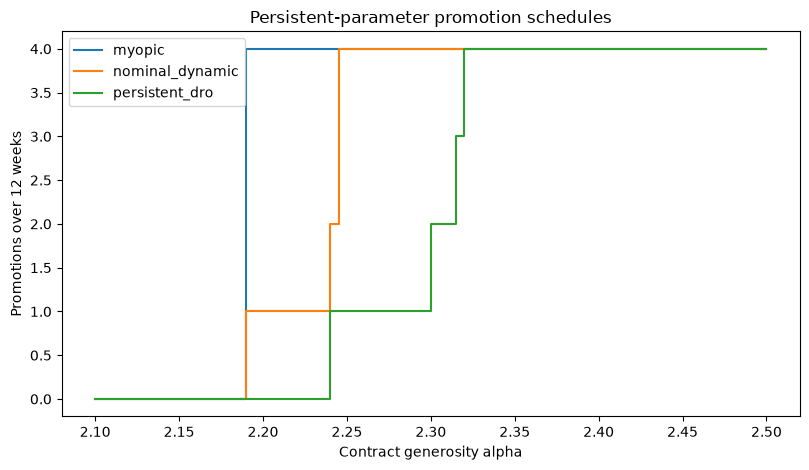

Saved: C:\Users\janza\price-of-extrapolation\results\figures\persistent_dro_promotion_count.png


In [16]:
fig, ax = plt.subplots(
    figsize=(8.2, 4.8)
)

for method, group in (
    selected_schedules.groupby(
        "method",
        observed=True,
    )
):
    ax.step(
        group[
            "alpha"
        ],
        group[
            "promotion_count"
        ],
        where="post",
        label=method,
    )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Promotions over 12 weeks"
)
ax.set_title(
    "Persistent-parameter promotion schedules"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PROMOTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    PROMOTION_FIGURE_PATH,
)

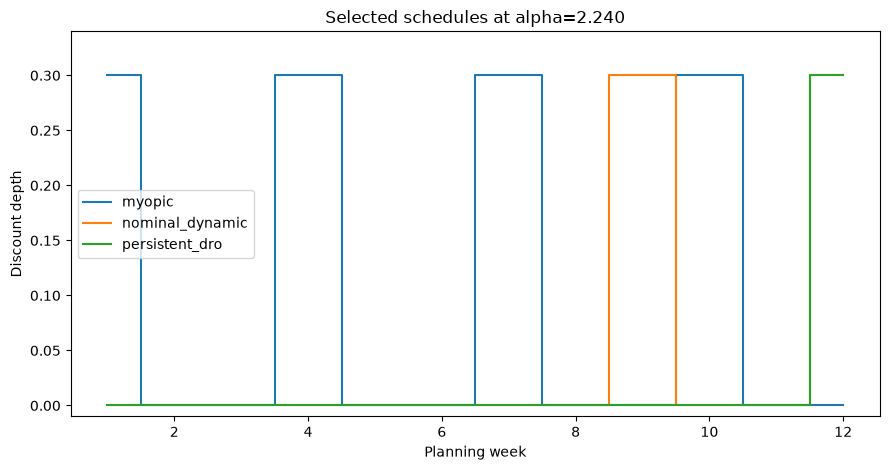

Saved: C:\Users\janza\price-of-extrapolation\results\figures\persistent_dro_selected_schedule.png


In [17]:
path_plot_alpha = float(
    thresholds.loc[
        thresholds[
            "decision_rule"
        ].eq(
            "persistent_dro"
        ),
        "alpha_threshold_grid",
    ].iloc[0]
)

path_plot = (
    selected_schedules.loc[
        np.isclose(
            selected_schedules[
                "alpha"
            ],
            path_plot_alpha,
        )
    ]
    .copy()
)

fig, ax = plt.subplots(
    figsize=(9, 4.8)
)

for row in path_plot.itertuples(
    index=False
):
    ax.step(
        np.arange(
            1,
            HORIZON + 1,
        ),
        np.asarray(
            row.schedule,
            dtype=float,
        ),
        where="mid",
        label=row.method,
    )

ax.set_xlabel(
    "Planning week"
)
ax.set_ylabel(
    "Discount depth"
)
ax.set_ylim(
    -0.01,
    float(
        DISCOUNT_ACTIONS.max()
    )
    + 0.04,
)
ax.set_title(
    f"Selected schedules at alpha={path_plot_alpha:.3f}"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    PATH_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    PATH_FIGURE_PATH,
)

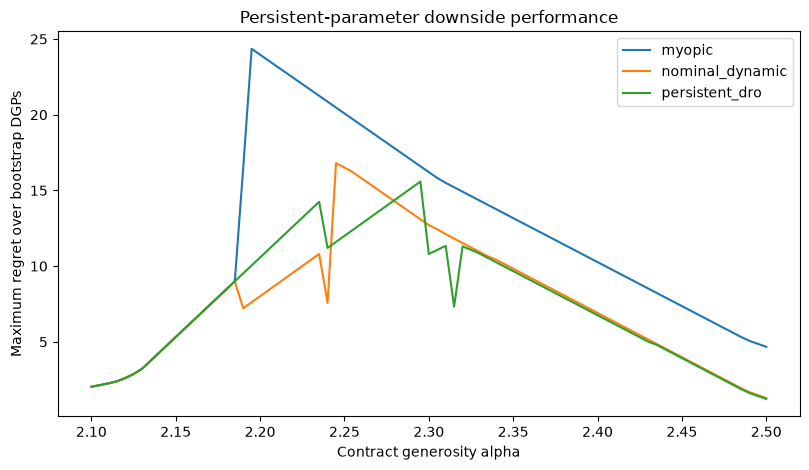

Saved: C:\Users\janza\price-of-extrapolation\results\figures\persistent_dro_regret.png


In [18]:
fig, ax = plt.subplots(
    figsize=(8.2, 4.8)
)

for method, group in (
    performance.groupby(
        "method",
        observed=True,
    )
):
    ax.plot(
        group[
            "alpha"
        ],
        group[
            "maximum_regret"
        ],
        label=method,
    )

ax.set_xlabel(
    "Contract generosity alpha"
)
ax.set_ylabel(
    "Maximum regret over bootstrap DGPs"
)
ax.set_title(
    "Persistent-parameter downside performance"
)
ax.legend()
fig.tight_layout()
fig.savefig(
    REGRET_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)
plt.show()

print(
    "Saved:",
    REGRET_FIGURE_PATH,
)

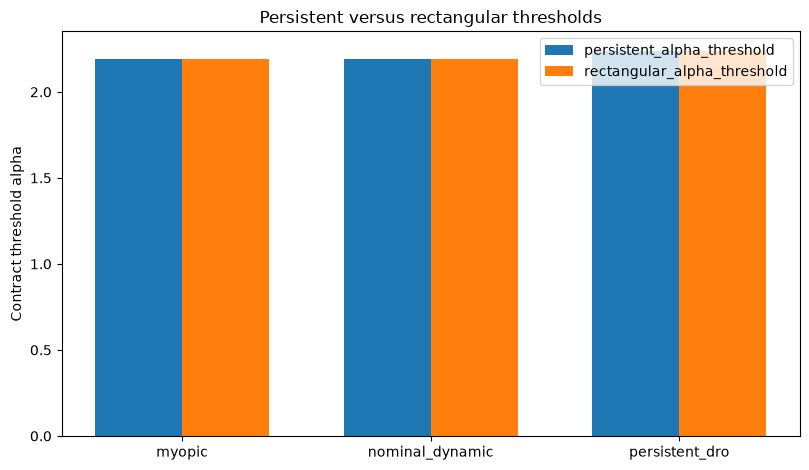

Saved: C:\Users\janza\price-of-extrapolation\results\figures\persistent_vs_rectangular_thresholds.png


In [19]:
if not rectangular_comparison.empty:
    threshold_plot = (
        rectangular_comparison.melt(
            id_vars=[
                "decision_rule"
            ],
            value_vars=[
                "persistent_alpha_threshold",
                "rectangular_alpha_threshold",
            ],
            var_name="formulation",
            value_name="alpha_threshold",
        )
    )

    methods = (
        threshold_plot[
            "decision_rule"
        ].unique()
    )

    formulations = [
        "persistent_alpha_threshold",
        "rectangular_alpha_threshold",
    ]

    x = np.arange(
        len(methods),
        dtype=float,
    )

    width = 0.35

    fig, ax = plt.subplots(
        figsize=(8.2, 4.8)
    )

    for formulation_index, formulation in enumerate(
        formulations
    ):
        values = []

        for method in methods:
            matched = (
                threshold_plot.loc[
                    threshold_plot[
                        "decision_rule"
                    ].eq(
                        method
                    )
                    & threshold_plot[
                        "formulation"
                    ].eq(
                        formulation
                    ),
                    "alpha_threshold",
                ]
            )

            values.append(
                float(
                    matched.iloc[0]
                )
                if not matched.empty
                else np.nan
            )

        offset = (
            formulation_index
            - 0.5
        ) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=formulation,
        )

    ax.set_xticks(
        x,
        methods,
    )
    ax.set_ylabel(
        "Contract threshold alpha"
    )
    ax.set_title(
        "Persistent versus rectangular thresholds"
    )
    ax.legend()
    fig.tight_layout()
    fig.savefig(
        THRESHOLD_FIGURE_PATH,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print(
        "Saved:",
        THRESHOLD_FIGURE_PATH,
    )

## 17. Diagnostics

In [20]:
search_diagnostics = (
    selected_schedules.loc[
        selected_schedules[
            "method"
        ].eq(
            "persistent_dro"
        ),
        [
            "alpha",
            "evaluated_schedule_count",
            "schedule_id",
            "promotion_count",
        ],
    ]
    .copy()
)

search_diagnostics[
    "evaluated_schedule_share"
] = (
    search_diagnostics[
        "evaluated_schedule_count"
    ]
    / N_SCHEDULES
)

print(
    "Median schedules evaluated per DRO problem:",
    int(
        search_diagnostics[
            "evaluated_schedule_count"
        ].median()
    ),
)
print(
    "Maximum schedules evaluated per DRO problem:",
    int(
        search_diagnostics[
            "evaluated_schedule_count"
        ].max()
    ),
)

monotonicity_rows = []

for method, group in (
    selected_schedules.groupby(
        "method",
        observed=True,
    )
):
    ordered = group.sort_values(
        "alpha"
    )

    promotion_count = (
        ordered[
            "promotion_count"
        ].to_numpy(dtype=float)
    )

    total_depth = (
        ordered[
            "total_discount_depth"
        ].to_numpy(dtype=float)
    )

    monotonicity_rows.append(
        {
            "method": method,
            "promotion_count_decreases": int(
                np.sum(
                    np.diff(
                        promotion_count
                    )
                    < 0
                )
            ),
            "total_depth_decreases": int(
                np.sum(
                    np.diff(
                        total_depth
                    )
                    < -1e-10
                )
            ),
            "unique_schedule_count": int(
                ordered[
                    "schedule_id"
                ].nunique()
            ),
        }
    )

monotonicity_diagnostics = pd.DataFrame(
    monotonicity_rows
)

display(
    monotonicity_diagnostics
)

if (
    divergence_grid[
        "divergence_type"
    ].eq(
        "same_schedule"
    ).all()
):
    warnings.warn(
        "Nominal and persistent-DRO schedules coincide "
        "throughout the tested contract range."
    )

Median schedules evaluated per DRO problem: 341
Maximum schedules evaluated per DRO problem: 2373


,method,promotion_count_decreases,total_depth_decreases,unique_schedule_count
0,myopic,0,0,3
1,nominal_dynamic,0,0,8
2,persistent_dro,0,0,8


## 18. Save outputs

In [21]:
schedule_table.to_csv(
    SCHEDULE_TABLE_PATH,
    index=False,
)

thresholds.to_csv(
    THRESHOLD_TABLE_PATH,
    index=False,
)

performance.to_csv(
    PERFORMANCE_TABLE_PATH,
    index=False,
)

selected_paths.to_csv(
    PATH_TABLE_PATH,
    index=False,
)

divergence_regions.to_csv(
    DIVERGENCE_TABLE_PATH,
    index=False,
)

oracle_threshold_table.to_csv(
    ORACLE_THRESHOLD_PATH,
    index=False,
)

search_diagnostics.to_csv(
    SEARCH_DIAGNOSTIC_PATH,
    index=False,
)

if not rectangular_comparison.empty:
    rectangular_comparison.to_csv(
        RECTANGULAR_COMPARISON_PATH,
        index=False,
    )

artifact = {
    "schedules": SCHEDULES,
    "schedule_promotion_count": (
        SCHEDULE_PROMOTION_COUNT
    ),
    "schedule_total_depth": (
        SCHEDULE_TOTAL_DEPTH
    ),
    "base_value_matrix": (
        BASE_VALUE_MATRIX
    ),
    "exposure_matrix": (
        EXPOSURE_MATRIX
    ),
    "draw_weights": DRAW_WEIGHTS,
    "scenario_indices": (
        medoid_indices
    ),
    "scenario_weights": (
        scenario_weights
    ),
    "transport_cost": (
        transport_cost
    ),
    "calibrated_rho": (
        CALIBRATED_RHO
    ),
    "alpha_grid": ALPHA_GRID,
    "selected_schedules": (
        selected_schedules
    ),
    "thresholds": thresholds,
    "performance": performance,
    "divergence_regions": (
        divergence_regions
    ),
    "oracle_thresholds": (
        oracle_threshold_table
    ),
}

pd.to_pickle(
    artifact,
    ARTIFACT_PATH,
)

configuration = {
    "uncertainty_model": (
        "behavioral_parameter_drawn_once_and_fixed_over_horizon"
    ),
    "decision_class": (
        "precommitted_open_loop_promotion_schedule"
    ),
    "contract_support": (
        "s_alpha(d)=alpha*d"
    ),
    "horizon": int(
        HORIZON
    ),
    "discount_factor": float(
        DISCOUNT_FACTOR
    ),
    "discount_actions": (
        DISCOUNT_ACTIONS.tolist()
    ),
    "cooldown_length": int(
        MIN_NONPROMOTION_WEEKS_AFTER_PROMOTION
    ),
    "maximum_promotions": int(
        MAX_PROMOTIONS
    ),
    "feasible_schedule_count": int(
        N_SCHEDULES
    ),
    "alpha_min": float(
        ALPHA_MIN
    ),
    "alpha_max": float(
        ALPHA_MAX
    ),
    "alpha_step": float(
        ALPHA_STEP
    ),
    "ambiguity_scenarios": int(
        len(
            scenario_weights
        )
    ),
    "wasserstein_radius": float(
        CALIBRATED_RHO
    ),
    "wasserstein_radius_interpretation": (
        "empirical_instability_calibration"
    ),
    "robust_search": (
        "exact_enumeration_with_nominal_upper_bound_pruning"
    ),
    "behavioral_model": (
        "Q0*(1-d)^(-epsilon)*"
        "exp(gamma*1[d>0]-psi*I);"
        "I_next=r*I+d"
    ),
}

CONFIGURATION_PATH.write_text(
    json.dumps(
        configuration,
        indent=2,
    ),
    encoding="utf-8",
)

print(
    "Saved artifact:",
    ARTIFACT_PATH,
)
print(
    "Saved thresholds:",
    THRESHOLD_TABLE_PATH,
)
print(
    "Saved performance:",
    PERFORMANCE_TABLE_PATH,
)
print(
    "Saved divergence regions:",
    DIVERGENCE_TABLE_PATH,
)

Saved artifact: C:\Users\janza\price-of-extrapolation\data\processed\persistent_parameter_dro_artifact.pkl
Saved thresholds: C:\Users\janza\price-of-extrapolation\results\tables\persistent_dro_contract_thresholds.csv
Saved performance: C:\Users\janza\price-of-extrapolation\results\tables\persistent_dro_contract_performance.csv
Saved divergence regions: C:\Users\janza\price-of-extrapolation\results\tables\persistent_dro_divergence_regions.csv


## Interpretation checklist

1. The persistent-\(\theta\) open-loop formulation is the main model.
   The rectangular feedback recursion is now an ablation.
2. The selected schedule is precommitted. It does not update beliefs
   about \(\theta\) after observing demand.
3. A feedback model with learning about a fixed latent behavioral type
   would require a belief-state formulation and is outside the present
   empirical design.
4. The nominal and oracle contract thresholds exploit the exact linear
   decomposition in \(\alpha\).
5. The persistent-DRO threshold is estimated on a \(0.005\) grid.
6. The robust search is exact over the enumerated schedule class because
   nominal schedule value is a valid upper bound on robust value.
7. Similar persistent and rectangular thresholds would validate the
   earlier approximation. Material differences would make the persistent
   result the headline estimate.
8. Contract thresholds remain counterfactual economic quantities, not
   estimates of the currently observed manufacturer agreement.
9. Profit and regret are model-based counterfactuals rather than realized
   causal effects.